In [27]:
import numpy as np
import matplotlib.pyplot as plt

import random
import pickle

/var/folders/7s/4vqyp_k94s93538md_k1q_sc0000gn/T/ipykernel_12725/2202874590.py:18: RuntimeWarning: invalid value encountered in sqrt
  distances = np.sqrt(2 * (1 - np.dot(vectors, vectors.T)))


Mean Distance: 1.4050520147689871
Median Distance: 1.4142955119799718
Average Variance: 0.04995516706104251
90th Percentile Distance: 1.6067887182749556
Small Distance Threshold (e.g., 10th Percentile): 1.1909577431014513


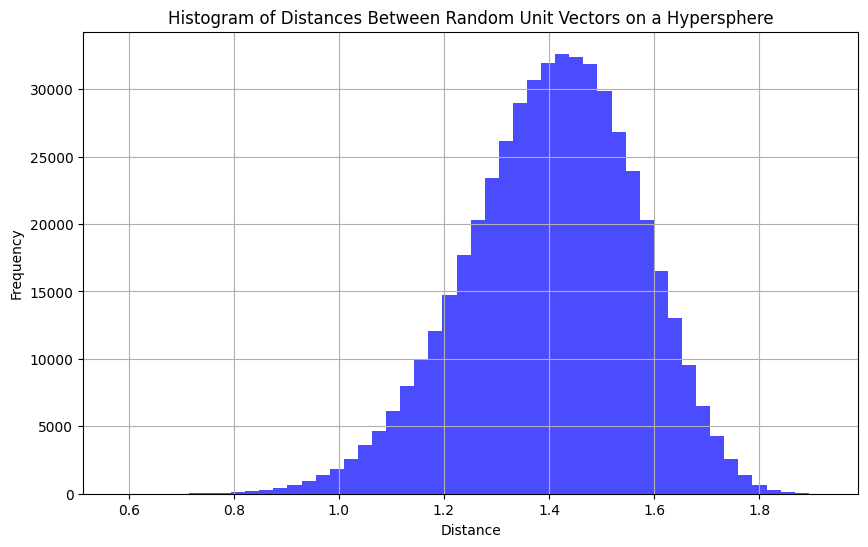

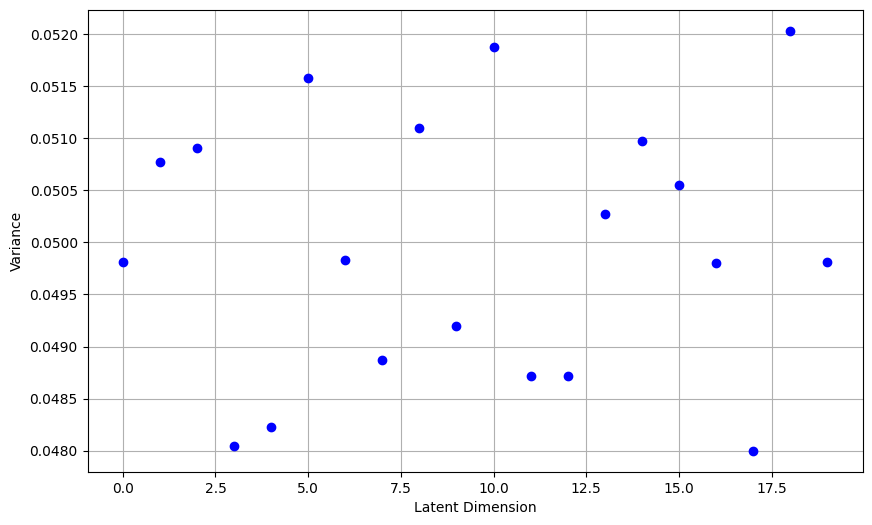

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def random_unit_vectors(n, d):
    """Generate n random unit vectors in d dimensions."""
    vecs = np.random.normal(0, 1, (n, d))
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    return vecs / norms

# Parameters
num_vectors = 1000  # Reduced for computational feasibility in the example
dimensions = 20

# Generate random unit vectors
vectors = random_unit_vectors(num_vectors, dimensions)

# Calculate distances
distances = np.sqrt(2 * (1 - np.dot(vectors, vectors.T)))
upper_triangle_distances = distances[np.triu_indices(num_vectors, k=1)]

# Analyze distances
print("Mean Distance:", np.mean(upper_triangle_distances))
print("Median Distance:", np.median(upper_triangle_distances))
print("Average Variance:", np.mean(np.var(vectors, axis=0)))
print("90th Percentile Distance:", np.percentile(upper_triangle_distances, 90))
print("Small Distance Threshold (e.g., 10th Percentile):", np.percentile(upper_triangle_distances, 10))

# Plot the histogram of the distances
plt.figure(figsize=(10, 6))
plt.hist(upper_triangle_distances, bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Distances Between Random Unit Vectors on a Hypersphere')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.grid(True)
# plt.savefig('../figures/histogram_distances_random_unit_vectors_d=20.png')

plt.figure(figsize=(10, 6))
plt.plot(np.var(vectors, axis=0), 'o', color='blue')
plt.xlabel('Latent Dimension')
plt.ylabel('Variance')
plt.grid(True)
# plt.savefig('../figures/variance_random_unit_vectors_d=20.png')


### Helper functions

In [2]:
fs = 14

In [3]:
def hslabeltoocc(hslabel, N):
    """
    Converts integer hilbert space label (hslabel) to anyon labels on bonds.
    N: number of bonds in the chain.
    Returns an integer array with 1 representing tau and 0 representing the identity
    """

    return np.array(list(np.binary_repr(hslabel, N)), dtype=int)


def occtohslabel(occ, N):
    """
    Converts array of anyon labels on bonds to integer label.
    N: number of bonds in the chain.
    """

    return int(''.join(map(str, occ)),2)

In [4]:
def H_tfim(N, J, h):
    ## setup the 1d transverse field ising model

    H_mat = np.zeros((2**N, 2**N))
    for i in range(2**N):
        state = hslabeltoocc(i,N)
        for site in range(N):
            if (site+1) < N:
                H_mat[i,i] += J*(2*state[site]-1)*(2*state[site+1]-1)
            stateflipped = state.copy()
            stateflipped[site] = abs(state[site]-1)
            H_mat[i,occtohslabel(stateflipped, N)] += h
    
    return -1 * H_mat


In [5]:
def cal_m(v, N):
    """
    Calculate the average magnetization of a given state
    input v: a state in hilbert space
    output m_tot: the total magnetization
    """

    m_tot = 0
    for i in range(len(v)):
        state = hslabeltoocc(i, N)
        num_up = np.count_nonzero(state)
        m = abs(2*num_up - N)
        m_tot += m * (np.conj(v[i])*v[i])
    return m_tot / N

### Generate Data

In [6]:
N = 10
J = 1

SSB phase is labeled as 1, and paramagnetic phase is labeled as 0.

In [46]:
# h_list = np.arange(0, 0.9991, 0.001)
# data_ssb = []
# for h in h_list:
#     e, v = np.linalg.eigh(H_tfim(N, J, h))
#     data_ssb.append({'h': h, 
#                       'e': e[:2], 
#                       'v': [v[:,0], v[:,1]], 
#                       'label': 1 if h<1 else 0})
    
# with open('data_ssb.pkl', 'wb') as f:
#     pickle.dump(data_ssb, f)

In [19]:
# h_list = np.arange(1.001, 2.001, 0.001)
# data_para = []
# for h in h_list:
#     e, v = np.linalg.eigh(H_tfim(N, J, h))
#     data_para.append({'h': h, 
#                       'e': e[:1], 
#                       'v': v[:,0], 
#                       'label': 1 if h<1 else 0})
    
# with open('data_para.pkl', 'wb') as f:
#     pickle.dump(data_para, f)

In [24]:
data_ssb = pickle.load(open('data_ssb.pkl', 'rb'))
data_para = pickle.load(open('data_para.pkl', 'rb'))

In [14]:
m_list = []

data_list = data_ssb + data_para
for item in data_list:
    if item['label'] == 1: gd = ( item['v'][0] + item['v'][1] ) / np.sqrt(2)
    else: gd = item['v'][0]
    m_list.append(cal_m(gd, N))


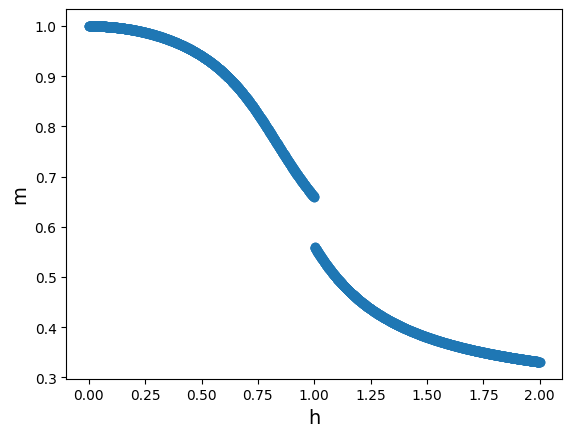

In [17]:
h_list = np.concatenate((np.arange(0, 0.9991, 0.001), np.arange(1.001, 2.001, 0.001)))
plt.plot(h_list, m_list,'o')
plt.xlabel('h', fontsize=fs)
plt.ylabel('m', fontsize=fs)
# plt.savefig('tfim_m.pdf')

The ground states obtained from the exact diagonalization of TFIM Hamiltonian in the ordered phases are two-fold degenerated. In order to reduce the bias in the data, we create linear superpositions of the two degenerate ground states for each h value. 

In [ ]:
np.random.seed(3452)

data_ssb_db = []

for item in data_ssb:
    gd1, gd2 = item['v'][0], item['v'][1]
    c1, c2 = np.random.normal(size=2)
    norm = np.sqrt(c1**2+c2**2)
    wf = (c1*gd1 + c2*gd2) / norm
    data_ssb_db.append({'h': item['h'], 'e': item['h'], 'v': wf, 'label': item['label']})

# with open('data_ssb_debiased.pkl', 'wb') as f:
#     pickle.dump(data_ssb_db, f)

Combine the ssb and para data them.

In [30]:
# data_ssb = pickle.load(open('data_ssb_debiased.pkl', 'rb'))
# data_para = pickle.load(open('data_para.pkl', 'rb')) 

# with open('tfim_data.pkl', 'wb') as f:
#     pickle.dump(data_ssb+data_para, f)

### Prepare data

In [26]:
# data_ssb = pickle.load(open('data_ssb_debiased.pkl', 'rb'))
# data_para = pickle.load(open('data_para.pkl', 'rb')) 
# print(len(data_ssb), data_ssb[0].keys())
# print(len(data_para), data_para[0].keys())

1000 dict_keys(['h', 'e', 'v', 'label'])
1000 dict_keys(['h', 'e', 'v', 'label'])


Set $70\%$ of the total data to training set and $30\%$ to testing set.

In [ ]:
# training_size = int(0.7 * len(data_ssb))
# testing_size = len(data_ssb) - training_size

# select_ssb = random.sample(range(0,len(data_ssb)), training_size)
# select_para = random.sample(range(0,len(data_para)), training_size)

In [ ]:
# train_data = []
# for i in select_ssb:
#     train_data.append({'data': data_ssb[i]['v'], 'label': data_ssb[i]['label']})
# for i in select_para:
#     train_data.append({'data': data_para[i]['v'], 'label': data_para[i]['label']})

# ## reshuffle the training data
# random.shuffle(train_data)